# Module import

In [302]:
import sys
sys.path.insert(1, "../../module")
import numpy as np      
import snflics
from skimage.transform import resize
from netCDF4 import Dataset                             
from scipy.ndimage import zoom
from matplotlib.patches import Rectangle                
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import matplotlib.pyplot as plt                         
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'
import warnings
warnings.filterwarnings("ignore")
from skimage import measure    
import json
from scipy.ndimage import label
import pandas as pd

# Matplotlib parameterisation

In [303]:
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'

# Geodata

In [304]:
geodata = np.load("../../data/geodata/lat_lon_2268_2080.npz")
lons = geodata["lon"][:]
lats = geodata["lat"][:]

# Core data

In [305]:
# file of interest at time t0

#file = "../../data/core/202307031815.nc"
file = "../../data/core/core_20230715/202307150000.nc"
data = Dataset(file, mode='r')

# wavelet power maxima's coordinates
x0_lat = data["max_lat"][:]
x0_lon = data["max_lon"][:]

# cloud top temperature and wavelet power arrays
temp = data["tir"][0, :, :]
cores = data["cores"][0, :, :]
binary_cores = (cores != 0).astype(int)

# Plotting cores

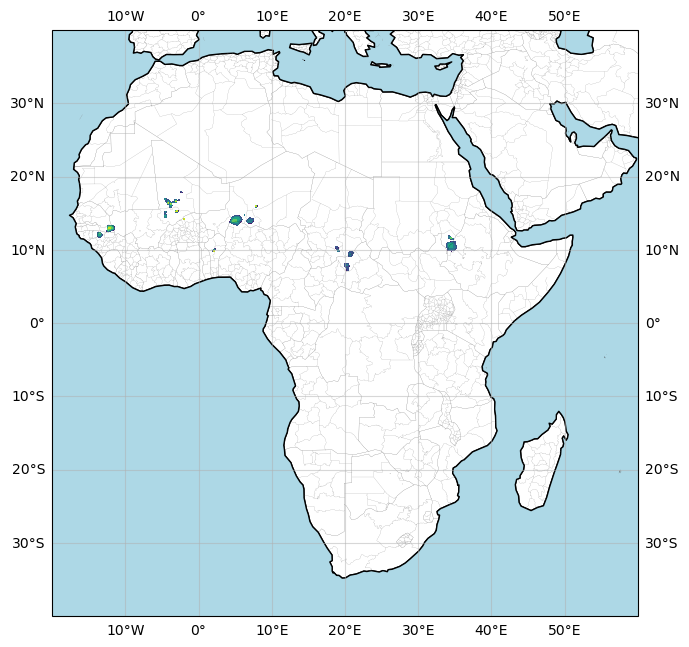

In [306]:
# Define extent
extent = (-20, 60, -40, 40)

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 9), subplot_kw={'projection': ccrs.PlateCarree()})

# Force background to white
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Set map extent
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')  # Optional

ax.gridlines(xlocs=np.arange(-20, 60, 10), 
             ylocs=np.arange(-40, 40, 10),
             draw_labels=True, 
             crs=ccrs.PlateCarree(),                
             alpha=0.5
            )

admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
    )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)
ax.add_feature(admin_borders, edgecolor='white', linewidth=0.07)

ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)

contour_core = ax.contourf(lons, lats, cores, levels=[40, 80, 120, 160, 200, 240, 280], transform=ccrs.PlateCarree(), cmap="viridis")

#for lt, ln in zip(x0_lat, x0_lon):    
  #plt.plot(ln, lt, marker="*", color="red", markersize=5)

plt.tight_layout()
plt.show()

### Finding all the cores (blobs)

- Using the average if we are interested in overall intensity, it is more robust

- less sensitive to noise

- useful for ranking general strenght or impact

What if I add some condition here to select only the wavelet power in the context domain?

In [307]:
# Long lead time (12x12)
CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX = 8.69, 20.69  # 8.69 + 12
CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX = -23.45, -11.45  # -23.45 + 12

In [308]:
in_region = (x0_lon >= CONTEXT_DOMAIN_LON_MIN) & (x0_lon <= CONTEXT_DOMAIN_LON_MAX) & (x0_lat >= CONTEXT_DOMAIN_LAT_MIN) & (x0_lat <= CONTEXT_DOMAIN_LAT_MAX)

In [309]:
in_region

masked_array(data=[False, False, False, False, False, False,  True,  True,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False],
             mask=False,
       fill_value=True)

In [315]:
x0_lon = x0_lon[in_region]
x0_lat = x0_lat[in_region]

In [316]:
# Label the storm cores
labeled_array, num_cores = label(cores != 0)
core_labels = np.unique(labeled_array[labeled_array != 0])

# Compute storm sizes and mean wavelet power
dict_storm_size = {
    core_label: int(np.sum(labeled_array == core_label)) * 9
    for core_label in core_labels
}

dict_storm_intensity = {
    core_label: np.mean(cores[labeled_array == core_label])
    for core_label in core_labels
}

# Assign storm properties to each labeled storm using x0 coordinates
storm_database = {}
for lat, lon in zip(x0_lat, x0_lon):
    x0_y, x0_x = snflics.to_yx(lat, lon, lats, lons)
    lab = labeled_array[x0_y, x0_x]
    
    # Skip points not associated with a storm or already added
    if lab == 0 or lab in storm_database:
        continue

    storm_database[int(lab)] = {
        "lat": lat,
        "lon": lon,
        "wp": (dict_storm_intensity[lab]),
        "size": dict_storm_size[lab],
    }

# Convert to pandas DataFrame
storm_df = pd.DataFrame.from_dict(storm_database, orient="index")
storm_df.index.name = "storm_label"
storm_df.reset_index(inplace=True)

In [317]:
storm_df

,storm_label,lat,lon,wp,size
0,7,12.233708,-13.484085,130.237762,3861
1,8,13.071183,-12.235099,164.910213,8019


In [318]:
len(storm_database) == len(x0_lat)

True

In [319]:
storm_database

{7: {'lat': 12.233708,
  'lon': -13.484085,
  'wp': 130.23776223776224,
  'size': 3861},
 8: {'lat': 13.071183,
  'lon': -12.235099,
  'wp': 164.91021324354656,
  'size': 8019}}

In [314]:
# with open("../../output/data/storm-input/data.json", "w") as f:
#     json.dump(storm_database, f, indent=4)

Create a function to return a certain number of closest storms